# Combined PT+MTMH Results (Custom Burn-in)

This notebook aggregates all datasets under `diagnosis/pt+mtmh_2000` and builds dataset-level boxplots using custom `START` (burn-in) and `END` (exclusive) indices.

- RMSE: one figure, each dataset is a subplot, each method is one box (runs are the samples; each run averages across chains).
- CRPS: same layout as RMSE, without TabPFN.
- Diagnostics: each diagnostic gets its own figure with dataset subplots.

In [1]:
from pathlib import Path
import ast
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from tabpfn import TabPFNRegressor
from ucimlrepo import fetch_ucirepo
from sklearn.datasets import fetch_california_housing

MODEL_SPECS = [
    ("default", "default", "tab:blue"),
    ("default_pt", "default_pt", "tab:orange"),
    ("mtmh", "mtmh", "tab:green"),
    ("mtmh_pt", "mtmh_pt", "tab:red"),
]

MODEL_COLORS = {key: color for key, _, color in MODEL_SPECS}
TABPFN_LABEL = "tabpfn"
TABPFN_COLOR = "tab:purple"

DATASET_NAMES = {
    "real1_Abalone_pt_mtmh": "Abalone",
    "real2_WineQuality_pt_mtmh": "WineQuality",
    "real3_CalHousing_pt_mtmh": "CalHousing",
    "real4_Concrete_pt_mtmh": "Concrete",
    "syn1_Friedman_pt_mtmh": "Friedman",
}

TABPFN_CACHE_DIR = Path("store") / "tabpfn_cache"
DATASET_CACHE_DIR = Path("store") / "dataset_cache"


def ensure_point_by_sample(arr, n_points):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={arr.shape}")
    if arr.shape[0] == n_points:
        return arr
    if arr.shape[1] == n_points:
        return arr.T
    raise ValueError(f"Could not align samples with n_points={n_points}, shape={arr.shape}")


def crps_from_samples(samples, y_true):
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples**2)
    return term1 - term2


def _load_numeric_csv(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    original_shape = None
    if header.startswith("# original_shape="):
        original_shape = ast.literal_eval(header[len("# original_shape="):])
    data = np.loadtxt(file_path, delimiter=",", comments="#", skiprows=1)
    data = np.asarray(data)
    if original_shape is not None:
        return data.reshape(original_shape)
    return data


def _load_metadata_csv(file_path):
    meta = pd.read_csv(file_path).set_index("key")["value"].to_dict()
    if "split_seed" in meta:
        meta["split_seed"] = int(meta["split_seed"])
    if "run_id" in meta:
        meta["run_id"] = int(meta["run_id"])
    return meta


def list_run_ids(store_root, setting_tag):
    meta_dir = store_root / "metadata"
    files = sorted(meta_dir.glob(f"{setting_tag}__run*.csv"))
    run_ids = []
    for f in files:
        stem = f.stem
        try:
            run_id = int(stem.split("__run")[-1])
            run_ids.append(run_id)
        except ValueError:
            continue
    return sorted(run_ids)


def load_run_from_store(store_root, setting_tag, run_id):
    run_tag = f"{setting_tag}__run{run_id:03d}"
    meta_path = store_root / "metadata" / f"{run_tag}.csv"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata CSV: {meta_path}")

    meta = _load_metadata_csv(meta_path)

    result = {
        "run_id": run_id,
        "split_seed": meta.get("split_seed"),
        "subsample": {
            "X_test": _load_numeric_csv(store_root / "subsample_X_test" / f"{run_tag}__subsample_X_test.csv"),
            "y_test": _load_numeric_csv(store_root / "subsample_y_test" / f"{run_tag}__subsample_y_test.csv").reshape(-1),
        },
        "models": {},
    }

    for model_key, _, _ in MODEL_SPECS:
        preds_path = store_root / "preds" / f"{run_tag}__{model_key}__preds.csv"
        if not preds_path.exists():
            raise FileNotFoundError(f"Missing preds CSV: {preds_path}")
        result["models"][model_key] = {
            "preds": _load_numeric_csv(preds_path),
        }

    return result


def slice_samples(samples, start, end):
    n_samples = samples.shape[1]
    end = n_samples if end is None else end
    if start < 0 or end > n_samples or start >= end:
        raise ValueError(f"Invalid slice: start={start}, end={end}, n_samples={n_samples}")
    return samples[:, start:end]


def _friedman_f(X):
    return (
        10.0 * np.sin(np.pi * X[:, 0] * X[:, 1])
        + 20.0 * (X[:, 2] - 0.5) ** 2
        + 10.0 * X[:, 3]
        + 5.0 * X[:, 4]
    )


def _dataset_cache_path(tag):
    return DATASET_CACHE_DIR / f"{tag}.npz"


def _load_cached_dataset(tag):
    cache_path = _dataset_cache_path(tag)
    if not cache_path.exists():
        return None
    data = np.load(cache_path)
    X = np.asarray(data["X"], dtype=float)
    y = np.asarray(data["y"], dtype=float).reshape(-1)
    return X, y


def _save_cached_dataset(tag, X, y):
    DATASET_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = _dataset_cache_path(tag)
    np.savez(cache_path, X=np.asarray(X, dtype=float), y=np.asarray(y, dtype=float))


def load_dataset_by_tag(tag):
    cached = _load_cached_dataset(tag)
    if cached is not None:
        X, y = cached
        if tag == "syn1_Friedman_pt_mtmh":
            return X, y, _friedman_f
        return X, y, None

    if tag == "real1_Abalone_pt_mtmh":
        try:
            abalone = fetch_ucirepo(id=1)
        except Exception as exc:
            raise RuntimeError(
                "Abalone dataset not cached and remote fetch failed. "
                "Please run once with internet or place a cached npz under store/dataset_cache."
            ) from exc
        X = abalone.data.features.drop(columns=["Sex"]).values.astype(float)
        y = np.asarray(abalone.data.targets).reshape(-1)
        _save_cached_dataset(tag, X, y)
        return X, y, None
    if tag == "real2_WineQuality_pt_mtmh":
        try:
            winequality = fetch_ucirepo(id=186)
        except Exception as exc:
            raise RuntimeError(
                "WineQuality dataset not cached and remote fetch failed. "
                "Please run once with internet or place a cached npz under store/dataset_cache."
            ) from exc
        X = winequality.data.features.values.astype(float)
        y = np.asarray(winequality.data.targets).reshape(-1)
        _save_cached_dataset(tag, X, y)
        return X, y, None
    if tag == "real3_CalHousing_pt_mtmh":
        data = fetch_california_housing(as_frame=True)
        X = data.data.values.astype(float)
        y = np.asarray(data.target).reshape(-1)
        n_samples = X.shape[0]
        subsample_size = 2000
        rng = np.random.default_rng(42)
        idx = rng.choice(n_samples, subsample_size, replace=False)
        X = X[idx]
        y = y[idx]
        _save_cached_dataset(tag, X, y)
        return X, y, None
    if tag == "real4_Concrete_pt_mtmh":
        try:
            concrete = fetch_ucirepo(id=165)
        except Exception as exc:
            raise RuntimeError(
                "Concrete dataset not cached and remote fetch failed. "
                "Please run once with internet or place a cached npz under store/dataset_cache."
            ) from exc
        X = concrete.data.features.values.astype(float)
        y = np.asarray(concrete.data.targets).reshape(-1)
        _save_cached_dataset(tag, X, y)
        return X, y, None
    if tag == "syn1_Friedman_pt_mtmh":
        rng = np.random.default_rng(42)
        n_samples = 2000
        noise_std = 1.0
        X = rng.uniform(0.0, 1.0, size=(n_samples, 10)).astype(float)
        eps = rng.normal(0.0, noise_std, size=n_samples)
        f_x = _friedman_f(X)
        y = np.asarray(f_x + eps).reshape(-1)
        _save_cached_dataset(tag, X, y)
        return X, y, _friedman_f

    raise ValueError(f"Unknown dataset tag: {tag}")


def _tabpfn_cache_path(tag, run_id, split_seed, n_points):
    fname = f"{tag}__run{run_id:03d}__seed{split_seed}__n{n_points}.npy"
    return TABPFN_CACHE_DIR / fname


def get_tabpfn_pred_cached(tag, run_id, split_seed, X, y, X_test_sub):
    TABPFN_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = _tabpfn_cache_path(tag, run_id, split_seed, X_test_sub.shape[0])

    if cache_path.exists():
        pred = np.load(cache_path)
        if pred.shape[0] == X_test_sub.shape[0]:
            return pred

    X_train, _, y_train, _ = train_test_split(X, y, random_state=split_seed)
    tabpfn_model = TabPFNRegressor(random_state=42, ignore_pretraining_limits=True)
    tabpfn_model.fit(X_train, y_train)
    pred = np.asarray(tabpfn_model.predict(X_test_sub), dtype=float).reshape(-1)
    np.save(cache_path, pred)
    return pred


def format_dataset_name(tag):
    return DATASET_NAMES.get(tag, tag.replace("_pt_mtmh", ""))

In [2]:
# User configuration
STORE_DIR = Path("store")
NOTEBOOK_DIR = Path(".")
START = 100  # 0-based, inclusive
END = 500   # 0-based, exclusive; set to None to use all remaining samples
SELECT_RUN_ID = 0
SELECT_CHAIN_ID = 0
PLOT_COLS = 2

NOTEBOOK_FILES = sorted(
    p for p in NOTEBOOK_DIR.glob("*_pt_mtmh.ipynb")
    if p.name != "combined_results_mtmh.ipynb"
)

SETTING_TAGS = [p.stem for p in NOTEBOOK_FILES]

if not SETTING_TAGS:
    raise RuntimeError("No *_pt_mtmh.ipynb notebooks found in this folder.")

In [3]:
if not STORE_DIR.exists():
    raise FileNotFoundError(f"Cannot find store directory: {STORE_DIR.resolve()}")

dataset_results = {}
# Cache TabPFN predictions per (dataset, run_id) since they only depend on the split.
tabpfn_cache = {}

for tag in SETTING_TAGS:
    X, y, f_func = load_dataset_by_tag(tag)
    run_ids = list_run_ids(STORE_DIR, tag)
    if not run_ids:
        print(f"Skipping {tag}: no runs found in store.")
        continue

    rmse_runs = {label: [] for _, label, _ in MODEL_SPECS}
    rmse_runs[TABPFN_LABEL] = []
    crps_runs = {label: [] for _, label, _ in MODEL_SPECS}

    for run_id in run_ids:
        run_data = load_run_from_store(STORE_DIR, tag, run_id)
        split_seed = run_data["split_seed"]
        if split_seed is None:
            raise ValueError(f"split_seed missing for {tag} run {run_id}")

        y_test_sub = np.asarray(run_data["subsample"]["y_test"], dtype=float).reshape(-1)
        X_test_sub = np.asarray(run_data["subsample"]["X_test"], dtype=float)

        cache_key = (tag, run_id)
        if cache_key in tabpfn_cache:
            tabpfn_pred = tabpfn_cache[cache_key]
        else:
            tabpfn_pred = get_tabpfn_pred_cached(tag, run_id, split_seed, X, y, X_test_sub)
            tabpfn_cache[cache_key] = tabpfn_pred

        tabpfn_rmse = float(root_mean_squared_error(y_test_sub, tabpfn_pred))
        rmse_runs[TABPFN_LABEL].append(tabpfn_rmse)

        for model_key, label, _ in MODEL_SPECS:
            preds_all = np.asarray(run_data["models"][model_key]["preds"], dtype=float)
            chain_rmse = []
            chain_crps = []
            for chain_id in range(preds_all.shape[0]):
                chain_pred = preds_all[chain_id]
                samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
                samples_slice = slice_samples(samples, START, END)
                pred_mean = np.mean(samples_slice, axis=1)
                chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
                chain_crps.append(float(np.mean(crps_from_samples(samples_slice, y_test_sub))))

            rmse_runs[label].append(float(np.mean(chain_rmse)))
            crps_runs[label].append(float(np.mean(chain_crps)))

    diag_run_id = SELECT_RUN_ID if SELECT_RUN_ID in run_ids else run_ids[0]
    diag_run = load_run_from_store(STORE_DIR, tag, diag_run_id)
    diag_y_test = np.asarray(diag_run["subsample"]["y_test"], dtype=float).reshape(-1)
    diag_X_test = np.asarray(diag_run["subsample"]["X_test"], dtype=float)

    pc1_by_model = {}
    samples_by_model = {}
    for model_key, _, _ in MODEL_SPECS:
        preds_all = np.asarray(diag_run["models"][model_key]["preds"], dtype=float)
        chain_id = min(SELECT_CHAIN_ID, preds_all.shape[0] - 1)
        chain_pred = preds_all[chain_id]
        samples = ensure_point_by_sample(chain_pred, n_points=diag_y_test.shape[0])
        samples_slice = slice_samples(samples, START, END)
        samples_by_model[model_key] = samples_slice
        pc1_by_model[model_key] = PCA(n_components=1).fit_transform(samples_slice.T).ravel()

    diag_tabpfn_key = (tag, diag_run_id)
    if diag_tabpfn_key in tabpfn_cache:
        diag_tabpfn_pred = tabpfn_cache[diag_tabpfn_key]
    else:
        diag_tabpfn_pred = get_tabpfn_pred_cached(tag, diag_run_id, diag_run["split_seed"], X, y, diag_X_test)
        tabpfn_cache[diag_tabpfn_key] = diag_tabpfn_pred

    joint_blocks = []
    joint_labels = []
    for model_key, label, _ in MODEL_SPECS:
        samples = samples_by_model[model_key]
        joint_blocks.append(samples.T)
        joint_labels.append(np.repeat(label, samples.shape[1]))

    joint_predictions = np.vstack(joint_blocks)
    joint_labels = np.concatenate(joint_labels)
    pca2 = PCA(n_components=2, random_state=42)
    joint_coords = pca2.fit_transform(joint_predictions)

    coords_by_label = {}
    for _, label, _ in MODEL_SPECS:
        coords_by_label[label] = joint_coords[joint_labels == label]

    tabpfn_coords = pca2.transform(diag_tabpfn_pred.reshape(1, -1))[0]
    y_test_coords = pca2.transform(diag_y_test.reshape(1, -1))[0]

    f_test_coords = None
    if f_func is not None:
        f_test_sub = np.asarray(f_func(diag_X_test), dtype=float).reshape(-1)
        f_test_coords = pca2.transform(f_test_sub.reshape(1, -1))[0]

    dataset_results[tag] = {
        "name": format_dataset_name(tag),
        "run_ids": run_ids,
        "rmse_runs": rmse_runs,
        "crps_runs": crps_runs,
        "diagnostics": {
            "run_id": diag_run_id,
            "chain_id": min(SELECT_CHAIN_ID, np.asarray(diag_run["models"][MODEL_SPECS[0][0]]["preds"]).shape[0] - 1),
            "pc1": pc1_by_model,
            "joint_coords": coords_by_label,
            "tabpfn_coords": tabpfn_coords,
            "y_test_coords": y_test_coords,
            "f_test_coords": f_test_coords,
            "explained_variance": pca2.explained_variance_ratio_,
        },
    }

print(f"Datasets loaded: {list(dataset_results.keys())}")

Datasets loaded: ['real1_Abalone_pt_mtmh', 'real2_WineQuality_pt_mtmh', 'real3_CalHousing_pt_mtmh', 'real4_Concrete_pt_mtmh', 'syn1_Friedman_pt_mtmh']


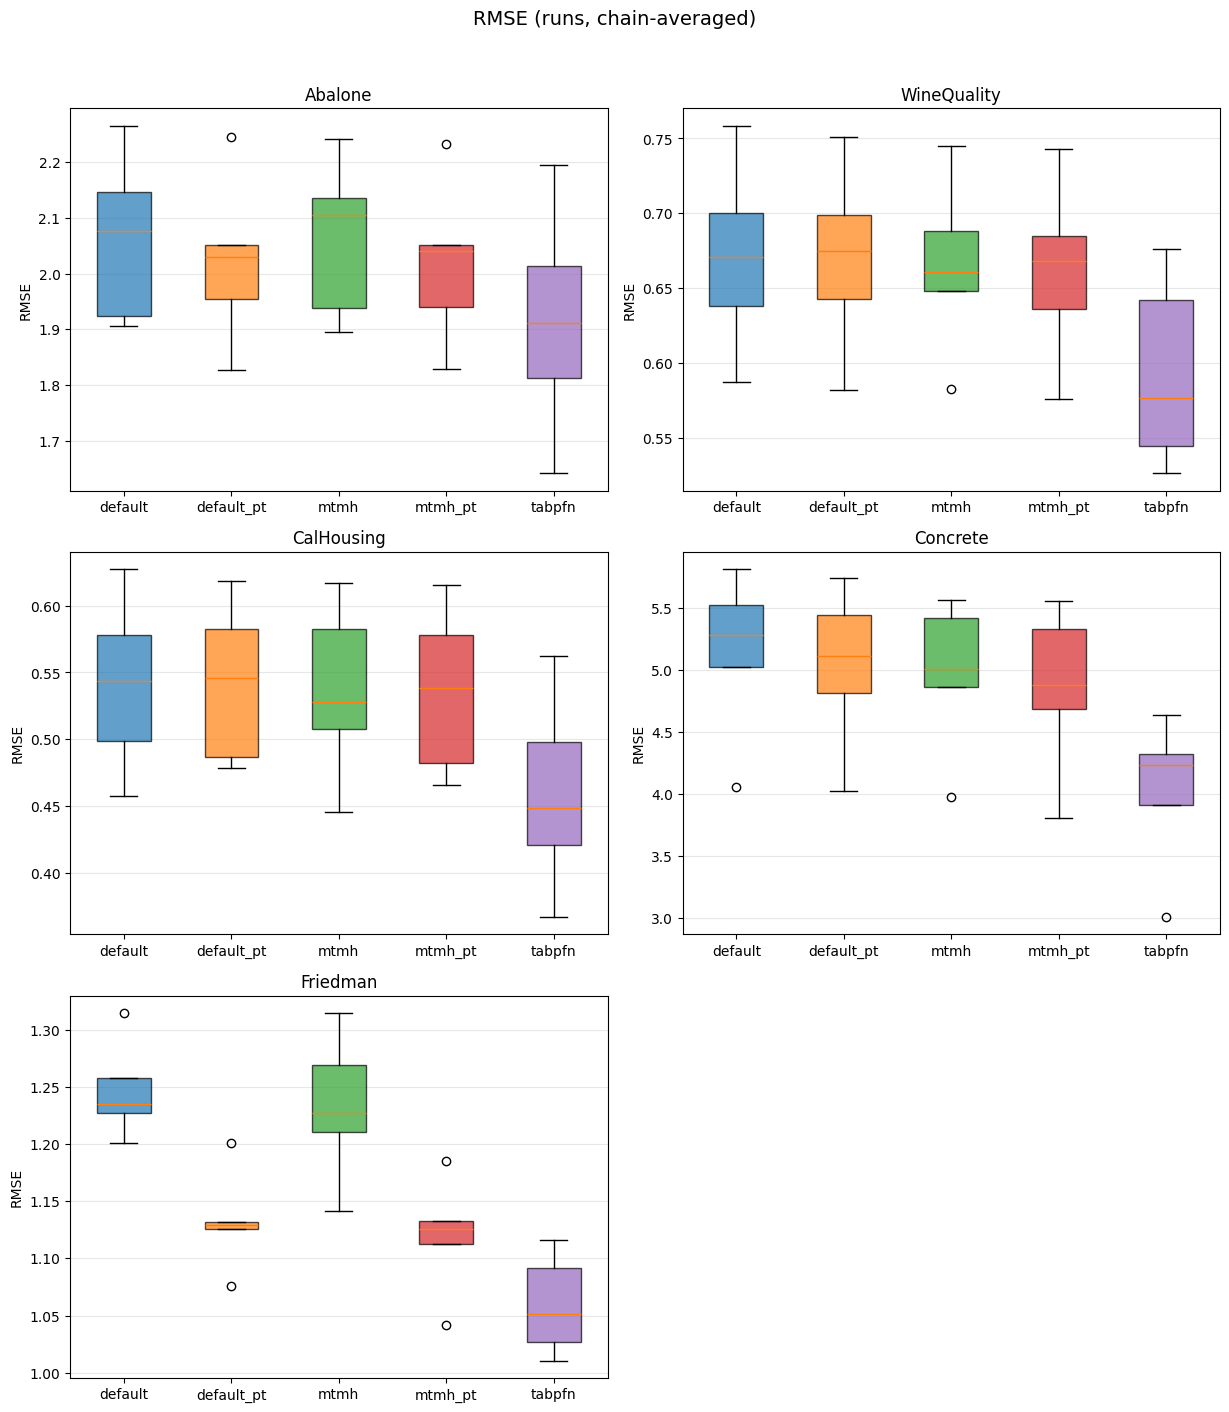

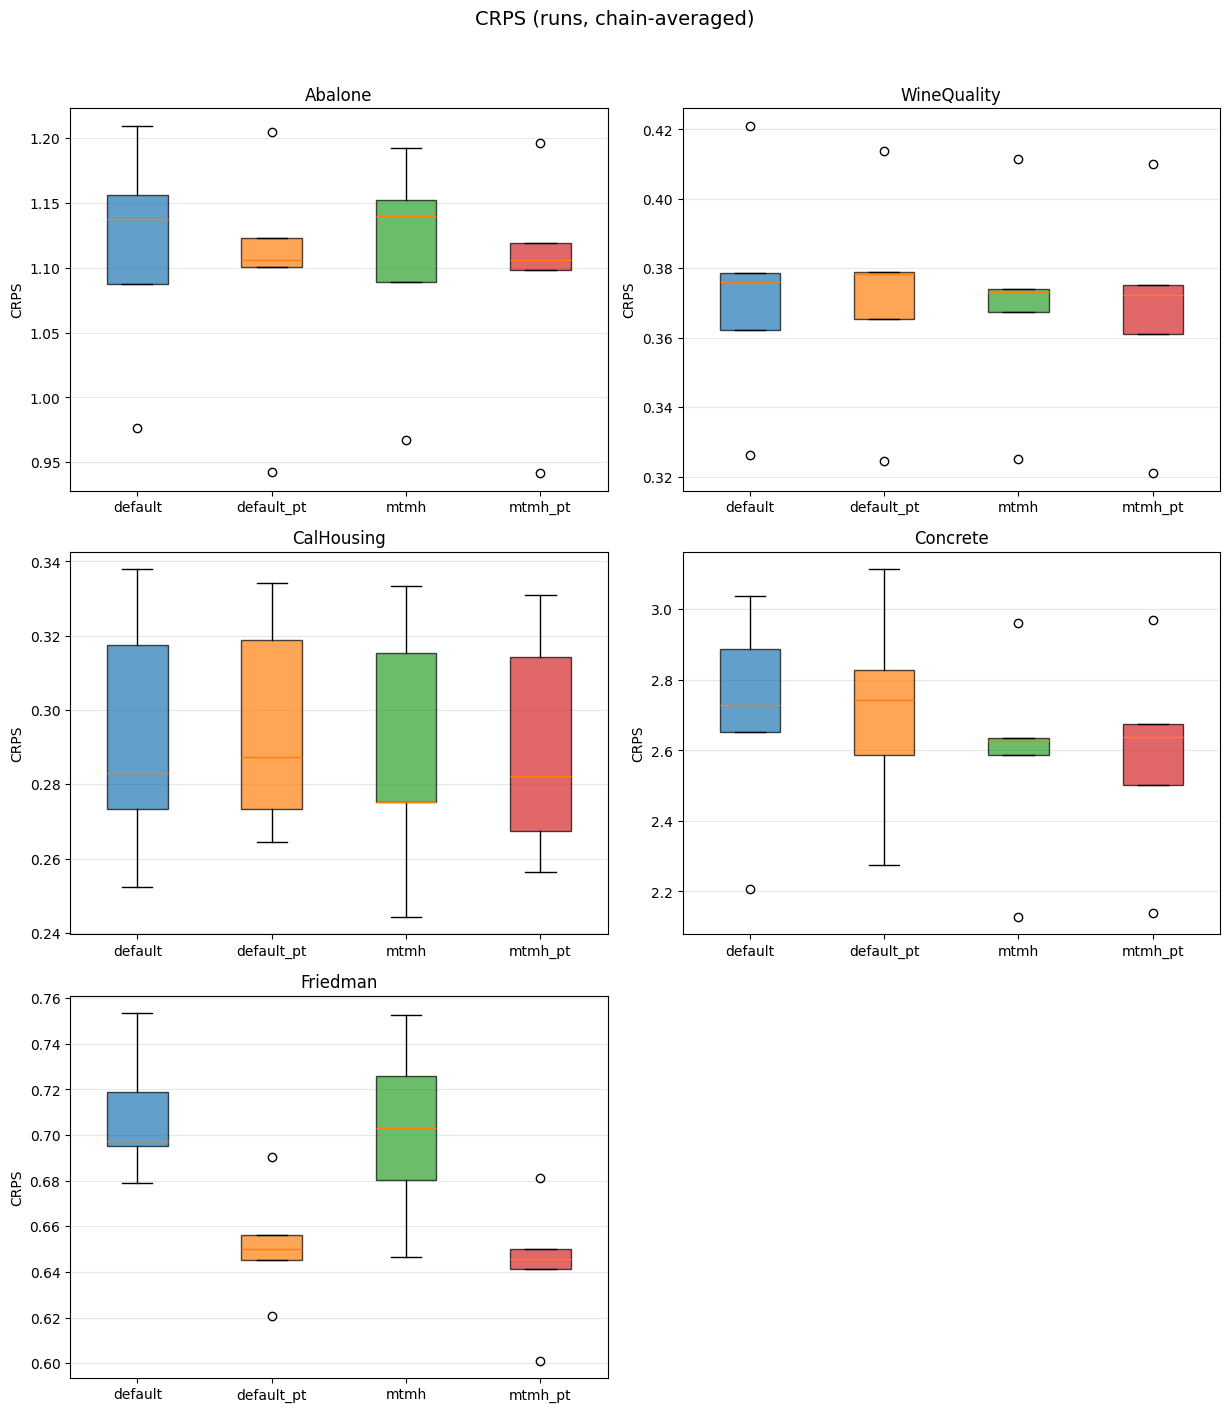

In [4]:
def _boxplot_axes(ax, data, labels, colors, title, ylabel):
    box = ax.boxplot(data, tick_labels=labels, patch_artist=True)
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)


def plot_metric_grid(metric_key, labels, colors, ylabel, title_prefix):
    items = list(dataset_results.items())
    n = len(items)
    n_cols = PLOT_COLS
    n_rows = int(math.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.6 * n_rows), squeeze=False)

    for ax, (tag, info) in zip(axes.flat, items):
        metric = info[metric_key]
        data = [metric[label] for label in labels]
        _boxplot_axes(ax, data, labels, colors, info["name"], ylabel)

    for ax in axes.flat[len(items):]:
        ax.axis("off")

    fig.suptitle(title_prefix, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


rmse_labels = [label for _, label, _ in MODEL_SPECS] + [TABPFN_LABEL]
rmse_colors = [MODEL_COLORS[key] for key, _, _ in MODEL_SPECS] + [TABPFN_COLOR]
crps_labels = [label for _, label, _ in MODEL_SPECS]
crps_colors = [MODEL_COLORS[key] for key, _, _ in MODEL_SPECS]

plot_metric_grid("rmse_runs", rmse_labels, rmse_colors, "RMSE", "RMSE (runs, chain-averaged)")
plot_metric_grid("crps_runs", crps_labels, crps_colors, "CRPS", "CRPS (runs, chain-averaged)")

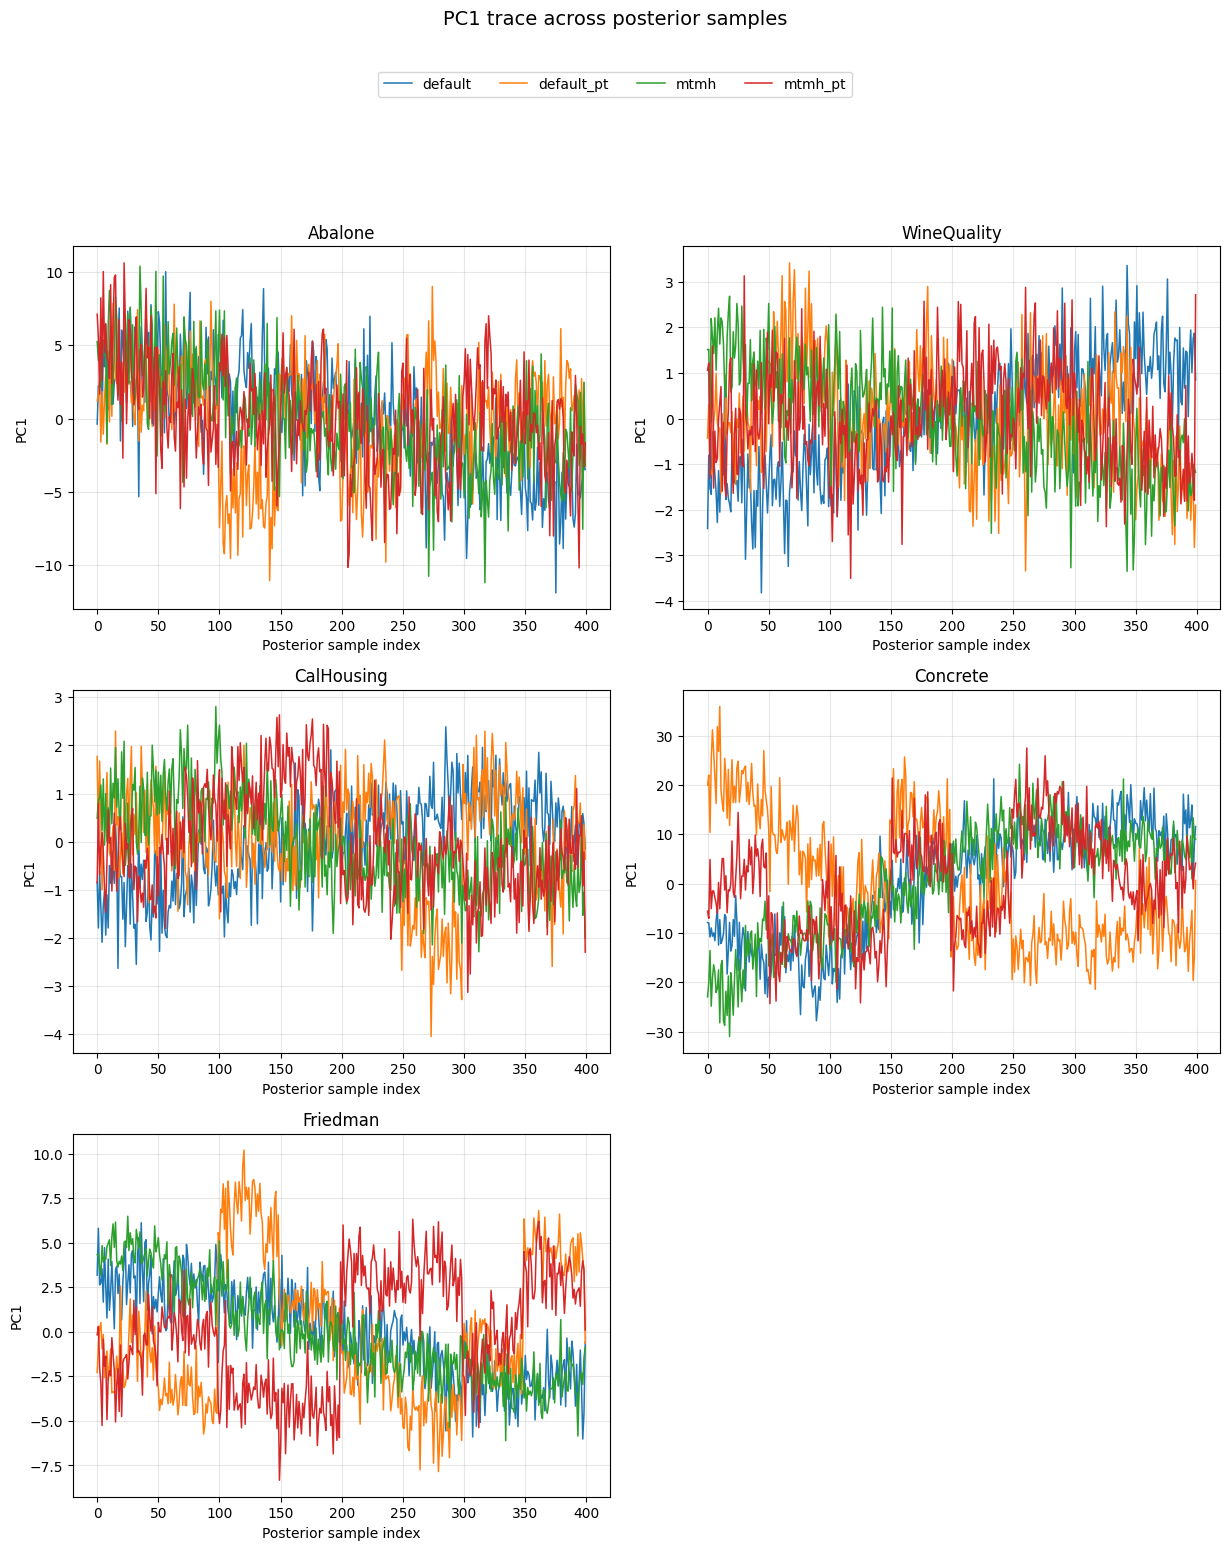

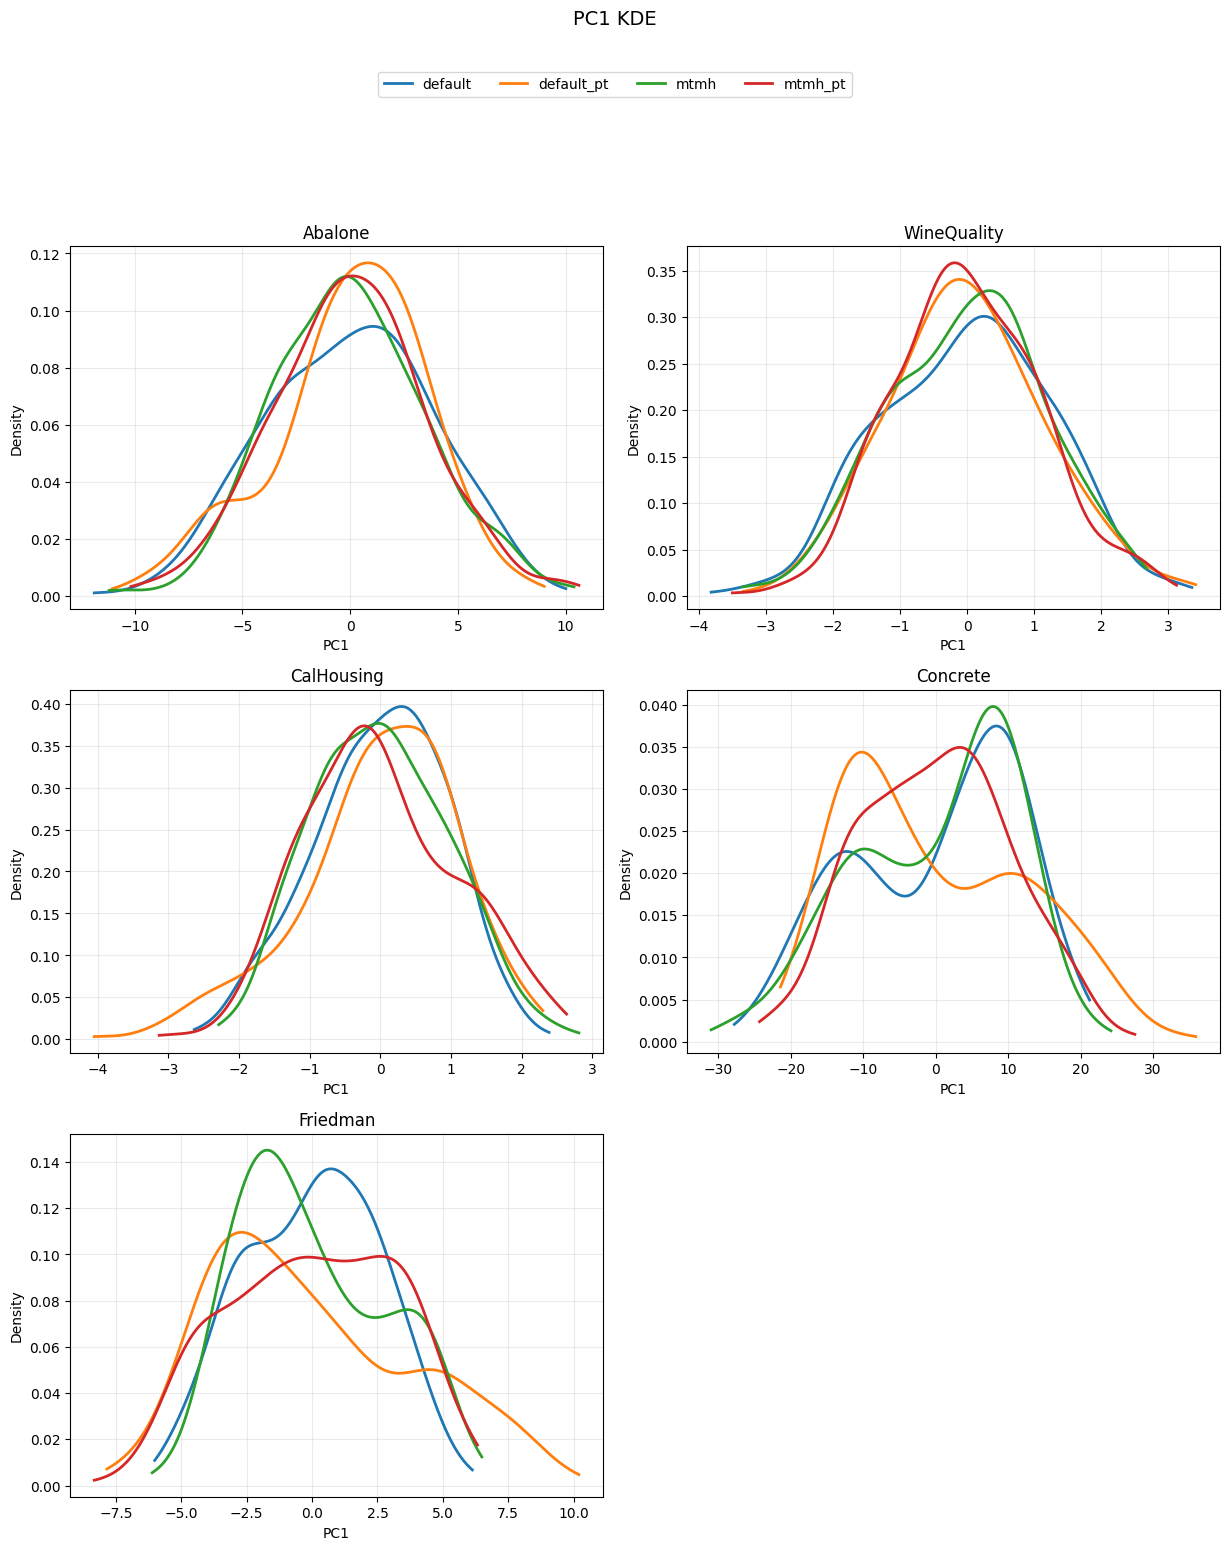

In [5]:
items = list(dataset_results.items())

n = len(items)
n_cols = PLOT_COLS
n_rows = int(math.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.6 * n_rows), squeeze=False)
for ax, (tag, info) in zip(axes.flat, items):
    diag = info["diagnostics"]
    for model_key, label, _ in MODEL_SPECS:
        ax.plot(diag["pc1"][model_key], lw=1.1, label=label, color=MODEL_COLORS[model_key])
    ax.set_title(info["name"])
    ax.set_xlabel("Posterior sample index")
    ax.set_ylabel("PC1")
    ax.grid(alpha=0.3)

for ax in axes.flat[len(items):]:
    ax.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("PC1 trace across posterior samples", y=1.12, fontsize=14)
fig.subplots_adjust(top=0.86)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.6 * n_rows), squeeze=False)
for ax, (tag, info) in zip(axes.flat, items):
    diag = info["diagnostics"]
    for model_key, label, _ in MODEL_SPECS:
        pc1 = diag["pc1"][model_key]
        x_grid = np.linspace(np.min(pc1), np.max(pc1), 300)
        kde = gaussian_kde(pc1)
        ax.plot(x_grid, kde(x_grid), color=MODEL_COLORS[model_key], linewidth=2.0, label=label)
    ax.set_title(info["name"])
    ax.set_xlabel("PC1")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.25)

for ax in axes.flat[len(items):]:
    ax.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("PC1 KDE", y=1.12, fontsize=14)
fig.subplots_adjust(top=0.86)
plt.tight_layout()
plt.show()

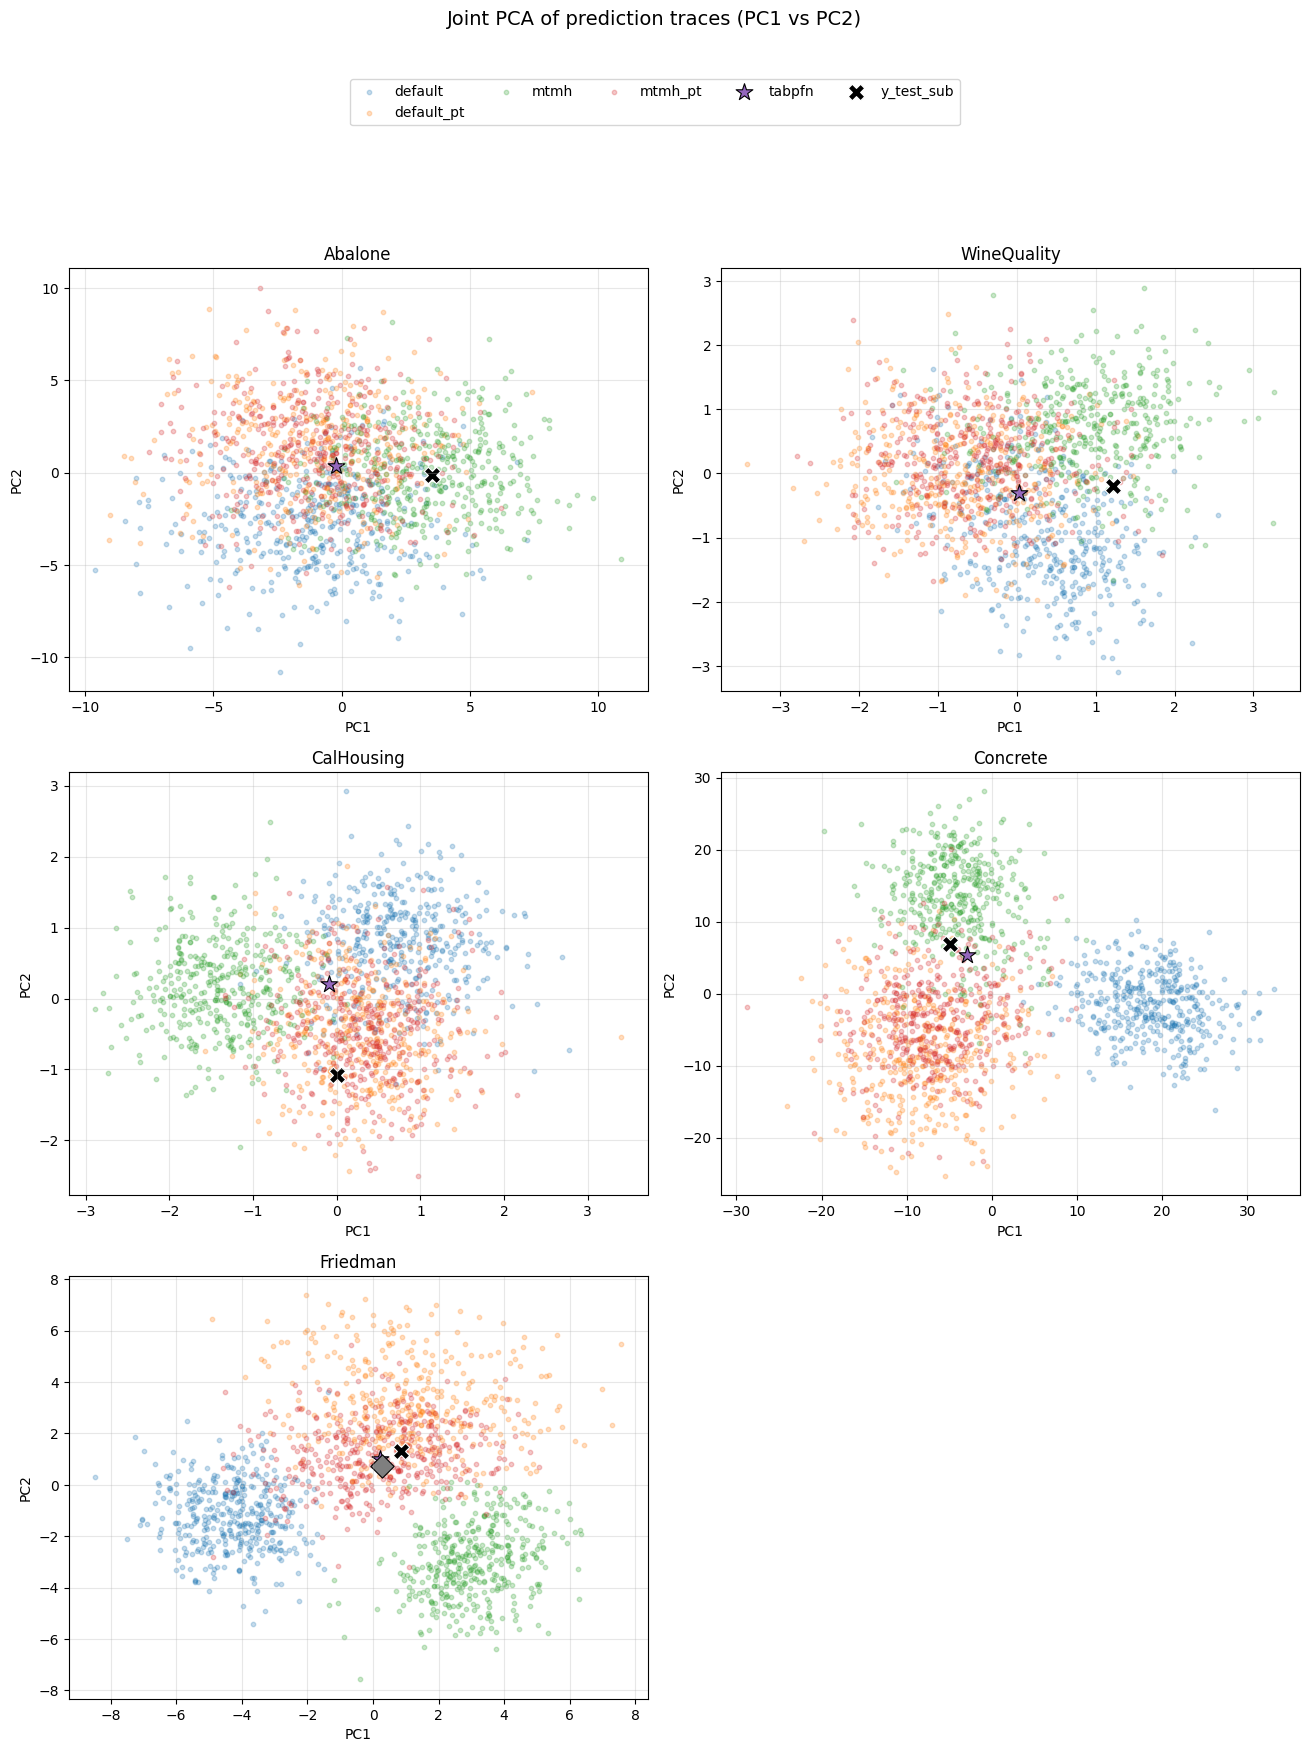

In [6]:
items = list(dataset_results.items())

n = len(items)
n_cols = PLOT_COLS
n_rows = int(math.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.6 * n_cols, 5.2 * n_rows), squeeze=False)
for ax, (tag, info) in zip(axes.flat, items):
    diag = info["diagnostics"]
    for _, label, _ in MODEL_SPECS:
        coords = diag["joint_coords"][label]
        ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.25, label=label)

    ax.scatter(
        diag["tabpfn_coords"][0], diag["tabpfn_coords"][1],
        s=160, marker="*", color=TABPFN_COLOR,
        edgecolor="black", linewidth=0.8, label="tabpfn",
    )
    ax.scatter(
        diag["y_test_coords"][0], diag["y_test_coords"][1],
        s=140, marker="X", color="black",
        edgecolor="white", linewidth=0.8, label="y_test_sub",
    )
    if diag["f_test_coords"] is not None:
        ax.scatter(
            diag["f_test_coords"][0], diag["f_test_coords"][1],
            s=140, marker="D", color="tab:gray",
            edgecolor="black", linewidth=0.8, label="f(X_test_sub)",
        )

    ax.set_title(info["name"])
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.3)

for ax in axes.flat[len(items):]:
    ax.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Joint PCA of prediction traces (PC1 vs PC2)", y=1.12, fontsize=14)
fig.subplots_adjust(top=0.86)
plt.tight_layout()
plt.show()